# Imports

In [1]:
%reload_ext autoreload
%autoreload 2


# import gdown
# import wget
# import pickle
import pandas as pd
import os
import sys
import numpy as np
# import shutil
import torch
# import pandas as pd
from tqdm import tqdm
# import xml.etree.ElementTree as ET
# import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    PrecisionRecallDisplay,
    roc_auc_score,
    roc_curve
)
# import scikitplot as skplt
import matplotlib.pyplot as plt
# import einops
# import tqdm
# import torch
# import PIL
# import shutil
# import open_clip
# import torchvision
# from torchvision.datasets import ImageFolder
# from torchvision.models import resnet50
# import torchvision.transforms as transforms

sys.path.insert(
    0,
    os.path.join(
        os.path.dirname(os.path.abspath('')), "src"
    )
)
import densifier
sys.path.insert(
    0,
    os.path.join(
        os.path.dirname(os.path.abspath(''))
    )
)
from debiasing import (
    make_models,
    get_uncertainty_score,
    optionally_make_dir
)
sys.path.pop(0)
from densifier.datasets.bboxed_dataset import (
    make_bboxed_dataset_from_config
)
from densifier.eval_clip.eval import (
    apply_visual_prompts,
    _build_timm_model,
    is_background
)
from densifier.utility.utils_for_notebooks import (
    # visualize_images_side_by_side,
    # show_image_and_mask,
    # load_data,
    # evaluate_model,
    make_symlink_cmd,
    tensor_for_matplotlib,
    # unnormalize,
    show_in_rows,
    batch_elements
)
from densifier.detection.uncertainty_scores import (
    div_continous_unique_per_sample,
    average_energy_per_sample,
    ens_entropy_per_sample,
    entropy,
    ens_conf_per_sample,
    get_probs
)
# from densifier.datasets.common import (
#     # DEFAULT_MEAN,
#     # DEFAULT_STD
# ) ??
sys.path.pop(0)

# from stuned.local_datasets.transforms import (
#     DEFAULT_MEAN_IN,
#     DEFAULT_STD_IN,
#     make_transforms
# )

from stuned.utility.utils import (
    show_images,
    load_from_pickle,
    append_dict
)
from stuned.local_datasets.imagenet1k import get_imagenet_dataset
from stuned.local_datasets.transforms import (
    DEFAULT_RESIZE_IN,
    DEFAULT_SIZE_IN,
    make_transforms,
    make_default_test_transforms_imagenet
)
from stuned.utility.utils import (
    get_project_root_path,
    load_from_pickle
)
from stuned.local_datasets.transforms import (
      make_default_test_transforms_imagenet,
      make_default_train_transforms_imagenet
)

CUR_DIR = os.path.abspath('')
DATA_PATH = os.path.join(os.path.dirname(CUR_DIR), "data")
# ?? import from datasets.common

# DEFAULT_MEAN = [0.485, 0.456, 0.406]
# DEFAULT_STD = [0.229, 0.224, 0.225]
MIN_NON_ZERO_PIXELS = 100
NUM_CORNER_PIXELS_FOR_BG = 5

/mnt/lustre/work/oh/arubinstein17/github/densification/envs/seg_env/lib/python3.10/site-packages/transformers/utils/generic.py:311: UserWarning: torch.utils._pytree._register_pytree_node is deprecated. Please use torch.utils._pytree.register_pytree_node instead.
  torch.utils._pytree._register_pytree_node(
/mnt/lustre/work/oh/arubinstein17/github/densification/envs/seg_env/lib/python3.10/site-packages/timm/models/layers/__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


# Functions

In [44]:
# def plot_multiple_pr_curves(labels_scores, title, pr=True):
#     plt.figure(figsize=(8, 6))  # Create a new figure
#     ax = plt.gca()  # Get the current axis
#     plot_chance_level = False
#     i = 0

#     # Iterate through the provided label and score pairs
#     for labels, scores, name in labels_scores:
#         if pr:
#             if i + 1 == len(labels_scores):
#                 plot_chance_level = True
#             display = PrecisionRecallDisplay.from_predictions(
#                 labels, scores, name=name, ax=ax, plot_chance_level=plot_chance_level
#             )
#             i += 1
#         else:
#             # skplt.metrics.plot_roc_curve(labels, scores)
#             # # plt.show()
#             fpr, tpr, _ = roc_curve(labels,  scores)
#             # auc = metrics.roc_auc_score(y_test, y_pred_proba)
#             # plt.plot(fpr, tpr, label=name)
#             ax.plot(fpr, tpr, label=name)
#             # plt.legend(loc=4)
#             # plt.show()

#     ax.set_title(title)
#     plt.legend(loc="best")  # Add a legend
#     plt.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.7)
#     plt.show()


def plot_multiple_pr_curves(labels_scores, title, pr=True, log_scale=False, fontsize=12, save_path=None):
    f = plt.figure(figsize=(8, 6))  # Create a new figure
    ax = plt.gca()  # Get the current axis
    plot_chance_level = False
    i = 0

    # Iterate through the provided label and score pairs
    for labels, scores, name in labels_scores:
        if pr:
            if i + 1 == len(labels_scores):
                plot_chance_level = True
            display = PrecisionRecallDisplay.from_predictions(
                labels, scores, name=name, ax=ax, plot_chance_level=plot_chance_level
            )
            i += 1
        else:
            # skplt.metrics.plot_roc_curve(labels, scores)
            # # plt.show()
            fpr, tpr, _ = roc_curve(labels,  scores)
            # auc = metrics.roc_auc_score(y_test, y_pred_proba)
            # plt.plot(fpr, tpr, label=name)
            ax.plot(fpr, tpr, label=name)
            # plt.legend(loc=4)
            # plt.show()
    if not pr:
        ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="y = x 'Random'")

    # Set log scale if requested
    if log_scale:
        ax.set_xscale("log")  # Set x-axis to log scale
        ax.set_yscale("log")  # Optionally, set y-axis to log scale if needed

    if title is not None:
        ax.set_title(title)
    plt.legend(loc="best", fontsize=fontsize)  # Add a legend
    # Set font size for axes labels and tick labels
    if not pr:
        ax.set_xlabel("False Positive Rate" if not pr else "Recall", fontsize=fontsize)
        ax.set_ylabel("True Positive Rate" if not pr else "Precision", fontsize=fontsize)
    ax.tick_params(axis='both', which='major', labelsize=fontsize)
    plt.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.7)
    plt.show()
    if save_path is not None:
        f.savefig(save_path)
    return f


def eval_model_list_on_dataloader(model_list, dataloader, device, max_samples=None):

    res = {}
    res["is_main_object"] = []

    for model_id, model in model_list:
        model.eval()
        model.to(device)
        res[model_id] = []

    # res[unc_type] = []

    with torch.no_grad():
        for i, batch in enumerate(tqdm(dataloader)):
            if max_samples is not None and i == max_samples:
                break
            # images, labels = batch[0], batch[1]
            assert batch[0].shape[0] == 1, "Implemented only for batch size 1"
            applied_mask, is_main_object = batch[4], batch[5]
            # image, label, bbox, mask, applied_mask, is_main_object
            applied_mask = applied_mask.to(device)
            is_main_object = is_main_object.to(device)
            for model_id, model in model_list:
                logits = model(applied_mask)
                res[model_id].append(logits)

            # uncertainty_score = get_uncertainty_score(logits, unc_type=unc_type)
            # res.append((uncertainty_score, is_main_object))
            # res[unc_type].append(uncertainty_score.item())
            res["is_main_object"].append(is_main_object.item())
    return res


# TODO(Alex | 23.09.2024): do this batchwise
def compute_unc(res, label_key):

    unc_scores = {}

    model_ids = []
    for model_id in res.keys():
        if model_id == label_key:
            continue
        # unc_scores[model_id] = {}
        model_ids.append(model_id)

    labels = res[label_key]
    unc_scores[label_key] = labels
    num_samples = len(labels)
    for sample_id in tqdm(range(num_samples)):
        stacked_logits = None
        for model_id in model_ids:
            logits = res[model_id][sample_id]
            append_dict(
                unc_scores,
                {model_id: {"conf": get_probs(logits).max().item()}},
                allow_new_keys=True
            )
            # print(unc_scores)
            append_dict(
                unc_scores,
                {model_id: {"entropy": [entropy(logits).item()]}},
                allow_new_keys=True
            )
            # print(unc_scores)
            # unc_scores[model_id]["conf"].append??
            # unc_scores[model_id]["entropy"] = entropy(logits).item()
            if stacked_logits is None:
                stacked_logits = logits.unsqueeze(0)
            else:
                stacked_logits = torch.cat([stacked_logits, logits.unsqueeze(0)], dim=0)
        append_dict(
            unc_scores,
            {"ensemble": {"PDS": [1 - div_continous_unique_per_sample(stacked_logits).item()]}},
            allow_new_keys=True
        )
        append_dict(
            unc_scores,
            {"ensemble": {"energy": [1 - average_energy_per_sample(stacked_logits).item()]}},
            allow_new_keys=True
        )
        append_dict(
            unc_scores,
            {"ensemble": {"ens_ent": [1 - ens_entropy_per_sample(stacked_logits).item()]}},
            allow_new_keys=True
        )
        append_dict(
            unc_scores,
            {"ensemble": {"ens_conf": [ens_conf_per_sample(stacked_logits).item()]}},
            allow_new_keys=True
        )
        # average_energy_per_sample
        # unc_scores["PDS"] = div_continous_unique_per_sample(stacked_logits).item()
    # ??
    return unc_scores

# OOD det

## Preparing dataloader

In [ ]:
# masks: line 7, 31hours https://docs.google.com/spreadsheets/d/1hiP7XRtH3IuFcbvxTjIEmoTsm1RMQyN3vi7sHG3fMok/edit?gid=1691421367#gid=1691421367
# bboxes: /home/oh/arubinstein17/github/densification/data/bboxes_annotations/val, from "Download bounding boxes" here: ./densification/notebooks/boundingboxes.ipynb
# parquet created by: eval_spurious + in_val_with_bboxes arg

In [ ]:
# make_df_with_foreground_scores(
#     source_df_path=parquets[split], # attention to mappers
#     images_path=images_path,
#     masks_path=masks_path,
#     separate_masks_folder=separate_masks_folder,
#     models_dict=_models_dict,
#     foreground_detectors=fg_detectors,
#     batch_size=args.batch_size,
#     dataset_name=args.dataset_name,
#     recompute_all=args.recompute_all
# )

<!-- # ./data/masks/in_val_masks_2008_0_10k.pkl

bbox_dataset_config["mapping_dict_path"] = "/home/oh/arubinstein17/github/densification/data/mapping_dicts/mapping_dict_in_val_full.pkl"
bbox_dataset_config["mask_per_value_folder"] = "/home/oh/arubinstein17/github/densification/data/masks_per_value/mask_per_value_in_val_full"
# bbox_dataset_config["masks_path"] = "/home/oh/arubinstein17/github/densification/data/masks/in_val_masks_2008.pkl"
bbox_dataset_config["masks_path"] = "/home/oh/arubinstein17/github/densification/data/masks/in_val_masks_2008.pkl"
bbox_dataset_config["train_val_split"] = 0.8
bbox_dataset_config["split_for_base_dataset"] = "val"
bbox_dataset_config["bboxes_folder"] = "/home/oh/arubinstein17/github/densification/data/bboxes_annotations/val"

# bboxed_dataset_5k = make_bboxed_dataset(
#     masks_path="/home/oh/arubinstein17/github/densification/data/masks/ImageNet_train_with_bboxes_5k_masks.pkl",
#     mapping_dict_path="./mapping_dict_5k.pkl",
#     mask_per_value_folder="./mask_per_value_5k"
# )
bboxed_dataset_in_val = make_bboxed_dataset_from_config(
    bbox_dataset_config,
    transform_type="eval"
) -->

In [3]:
# bboxed_dataset_config = {

#       "csv_path": "/mnt/lustre/work/oh/arubinstein17/github/densification/data/csvs/cropformer/source_in_val_with_bboxes_cropformer.parquet",
#       # csv_path: /home/oh/arubinstein17/github/densification/data/csvs/counter_debug.parquet
#       "dataset_task": "detection",
#       "eval_transform": make_default_test_transforms_imagenet(),
#       "train_transform": None,
#       "train_val_split": 0.0,
#       "foreground_keyword": "bbox_iou" # is_main_object is decided based on bbox_iou
# }

# bboxed_dataset = make_bboxed_dataset_from_config(
#       bboxed_dataset_config=bboxed_dataset_config,
#       transform_type="eval"
# )
# # 3m30s

In [ ]:
# compute curve for oracle based on columns bbox_iou and model_name---oracle from parquet

In [4]:
# # dataloader
# dataloader = torch.utils.data.DataLoader(
#     bboxed_dataset,
#     batch_size=1,
#     shuffle=False,
#     num_workers=12,
#     # prefetch_factor=6
# )

In [11]:
bboxed_dataset_config_oracle = {

    "csv_path": "/mnt/lustre/work/oh/arubinstein17/github/densification/data/csvs/cropformer/source_in_val_with_bboxes_cropformer.parquet",
    #   "csv_path": "/home/oh/arubinstein17/github/densification/data/csvs/cropformer/source_urban_cars_cropformer.parquet", # to speed up debug
    # csv_path: /home/oh/arubinstein17/github/densification/data/csvs/counter_debug.parquet
    "dataset_task": "detection",
    "eval_transform": make_default_test_transforms_imagenet(),
    "train_transform": None,
    "train_val_split": 0.0,
    # "foreground_keyword": "bbox_iou" # is_main_object is decided based on bbox_iou
    "foreground_keyword": "oracle---clip_openai_ViT-L/14" # oracle field
}

# bboxed_dataset_oracle = make_bboxed_dataset_from_config(
#     bboxed_dataset_config=bboxed_dataset_config_oracle,
#     transform_type="eval"
# )
# # 3m30s when loading in_val data
# # if False:

# # dataloader
# dataloader_oracle = torch.utils.data.DataLoader(
#     bboxed_dataset_oracle,
#     batch_size=1,
#     shuffle=False,
#     num_workers=12,
#     # prefetch_factor=6
# )
# # 4m30s

In [12]:
parquet = pd.read_parquet(bboxed_dataset_config_oracle["csv_path"])
# 5m16s


In [9]:
def extract_foreground_score(parquet_column):
    res = []
    for oracle_value in tqdm(parquet_column):
        for key, value in oracle_value.items():
            if value is not None:
                fg_score_value = float(value['foreground_score'])
                res.append(fg_score_value)
                break
    return res

In [7]:
# get oracle results
oracle_results = []

for oracle_value in tqdm(parquet["oracle---clip_openai_ViT-L/14_metadata"]):
    for key, value in oracle_value.items():
        if value is not None:
            fg_score_value = float(value['foreground_score'])
            oracle_results.append(fg_score_value)
            break

    print(fg_score_value)
    break
    oracle_results.append(float(oracle_value))

  0%|          | 0/605835 [00:00<?, ?it/s]

0.001


In [10]:
oracle_results = extract_foreground_score(parquet["oracle---clip_openai_ViT-L/14_metadata"])

100%|██████████| 605835/605835 [00:02<00:00, 241851.46it/s]


In [12]:
oracle_path = "/home/oh/arubinstein17/github/densification/data/results/ood_detection/oracle_results.pkl"
optionally_make_dir(oracle_path)
torch.save(oracle_results, oracle_path)

In [ ]:
# bboxed_dataset_config_iou = {

#     "csv_path": "/mnt/lustre/work/oh/arubinstein17/github/densification/data/csvs/cropformer/source_in_val_with_bboxes_cropformer.parquet",
#     #   "csv_path": "/home/oh/arubinstein17/github/densification/data/csvs/cropformer/source_urban_cars_cropformer.parquet", # to speed up debug
#     # csv_path: /home/oh/arubinstein17/github/densification/data/csvs/counter_debug.parquet
#     "dataset_task": "detection",
#     "eval_transform": make_default_test_transforms_imagenet(),
#     "train_transform": None,
#     "train_val_split": 0.0,
#     "foreground_keyword": "bbox_iou" # is_main_object is decided based on bbox_iou
#     # "foreground_keyword": "oracle---open_clip_ViT-L/14" # oracle field
# }

# bboxed_dataset_iou = make_bboxed_dataset_from_config(
#     bboxed_dataset_config=bboxed_dataset_config_iou,
#     transform_type="eval"
# )
# # 3m30s when loading in_val data
# # if False:

# # dataloader
# dataloader_iou = torch.utils.data.DataLoader(
#     bboxed_dataset_iou,
#     batch_size=1,
#     shuffle=False,
#     num_workers=12,
#     # prefetch_factor=6
# )

In [ ]:
# # get oracle results
# iou_results = []

# # for batch in tqdm(dataloader_iou):
# for iou_value in tqdm(parquet["bbox_iou"]):
#     iou_results.append(float(iou_value))

In [18]:
# iou_results = extract_foreground_score(parquet["bbox_iou_metadata"])
iou_results = []
for iou_value in tqdm(parquet["bbox_iou_label"]):
    iou_results.append(int(iou_value))
# return res

100%|██████████| 605835/605835 [00:00<00:00, 2469653.54it/s]


In [19]:
iou_path = "/home/oh/arubinstein17/github/densification/data/results/ood_detection/iou_results.pkl"
optionally_make_dir(iou_path)
torch.save(iou_results, iou_path)

## CLIP confidences

In [20]:
unc_scores_path_clips = "/home/oh/arubinstein17/github/densification/data/results/uncertainty_scores/5clips_ensemble_unc_scores.pkl"
oracle_results = torch.load("/home/oh/arubinstein17/github/densification/data/results/ood_detection/oracle_results.pkl")
iou_results = torch.load("/home/oh/arubinstein17/github/densification/data/results/ood_detection/iou_results.pkl")
unc_scores_clips = torch.load(unc_scores_path_clips)

In [27]:
print(unc_scores_clips['clip_openclip_datacomp_xl_s13b_b90k_ViT-L-14']['entropy'][:10])

[[-24254.359375], [nan], [nan], [-29174.615234375], [nan], [nan], [-24964.66796875], [-24214.080078125], [-35571.53125], [-28793.560546875]]


In [32]:
def clean_from_nan(main_object_values, entropy_values):
    res_main_object = []
    res_ent = []
    for i in range(len(entropy_values)):
        if not np.isnan(entropy_values[i][0]):
            res_ent.append(entropy_values[i][0])
            res_main_object.append(main_object_values[i])
    return res_main_object, res_ent


def print_roc_auc_scores(model_names, unc_scores):

    for model_id in model_names:
        print(f"{model_id} conf:", roc_auc_score(unc_scores["is_main_object"], unc_scores[model_id]["conf"]))

    for model_id in model_names:
        main_object_values = unc_scores["is_main_object"]
        entropy_values = unc_scores[model_id]["entropy"]
        # res_ent = []
        # res_main_object = []
        # for i in range(len(entropy_values)):
        #     if not np.isnan(entropy_values[i][0]):
        #         res_ent.append(entropy_values[i][0])
        #         res_main_object.append(main_object_values[i])
        res_main_object, res_ent = clean_from_nan(main_object_values, entropy_values)
        print(f"{model_id} entropy:", roc_auc_score(res_main_object, res_ent))

    print("Energy:", roc_auc_score(unc_scores["is_main_object"], unc_scores['ensemble']["energy"]))
    print("PDS:", roc_auc_score(unc_scores["is_main_object"], unc_scores['ensemble']["PDS"]))
    print("ens_ent:", roc_auc_score(unc_scores["is_main_object"], unc_scores['ensemble']["ens_ent"]))
    print("ens_conf:", roc_auc_score(unc_scores["is_main_object"], unc_scores['ensemble']["ens_conf"]))
    print("Oracle:", roc_auc_score(iou_results, oracle_results))

In [34]:
import numpy as np

In [35]:
# print(roc_auc_score("resnet18.a1_in1k conf:", unc_scores["is_main_object"], unc_scores['resnet18.a1_in1k']["conf"]))
# print(roc_auc_score("resnet50.a1_in1k conf:", unc_scores["is_main_object"], unc_scores['resnet50.a1_in1k']["conf"]))
# print(roc_auc_score("resnet50.a1_in1k conf:", unc_scores["is_main_object"], unc_scores['resnet50.a1_in1k']["conf"]))
# print(roc_auc_score("resnet50.a1_in1k conf:", unc_scores["is_main_object"], unc_scores['resnet50.a1_in1k']["conf"]))
# print(roc_auc_score("resnet50.a1_in1k conf:", unc_scores["is_main_object"], unc_scores['resnet50.a1_in1k']["conf"]))
# # print(roc_auc_score(unc_scores["is_main_object"], unc_scores['resnet50.a1_in1k']["entropy"]))

# models = [
#     'resnet50.a1_in1k',
#     'resnet18.a1_in1k',
#     'vit_base_patch8_224.augreg2_in21k_ft_in1k',
#     'tf_efficientnet_b1.ns_jft_in1k',
#     'efficientnet_lite0.ra_in1k'
# ]




model_names_clips = [
    "clip_openclip_datacomp_xl_s13b_b90k_ViT-L-14",
    "clip_openclip_dfn2b_ViT-L-14-quickgelu",
    "clip_openclip_openai_ViT-L-14",
    "clip_openclip_laion400m_e31_ViT-L-14",
    "clip_openclip_laion400m_e32_ViT-L-14"
]

print_roc_auc_scores(model_names_clips, unc_scores_clips)

clip_openclip_datacomp_xl_s13b_b90k_ViT-L-14 conf: 0.8528856798018023
clip_openclip_dfn2b_ViT-L-14-quickgelu conf: 0.858753443603298
clip_openclip_openai_ViT-L-14 conf: 0.8827563147755241
clip_openclip_laion400m_e31_ViT-L-14 conf: 0.8185769254771473
clip_openclip_laion400m_e32_ViT-L-14 conf: 0.8174406930779203
clip_openclip_datacomp_xl_s13b_b90k_ViT-L-14 entropy: 0.5871218285908726
clip_openclip_dfn2b_ViT-L-14-quickgelu entropy: 0.7146540809833652
clip_openclip_openai_ViT-L-14 entropy: 0.8381674293785881
clip_openclip_laion400m_e31_ViT-L-14 entropy: 0.584931265697407
clip_openclip_laion400m_e32_ViT-L-14 entropy: 0.5664048755575585
Energy: 0.8452919682608895
PDS: 0.8761992113328302
ens_ent: 0.9168269139068542
ens_conf: 0.8902566040794447
Oracle: 0.9095240951615946


In [7]:
print(unc_scores_clips["is_main_object"][:10])

[0, 0, 1, 0, 1, 0, 0, 0, 0, 0]


In [21]:
print(iou_results[:10])

[0, 0, 1, 0, 1, 0, 0, 0, 0, 0]


In [9]:
print(oracle_results[:10])

[0.001, 0.039, 0.022, 0.0, 0.851, 0.029, 0.003, 0.006, 0.0, 0.001]


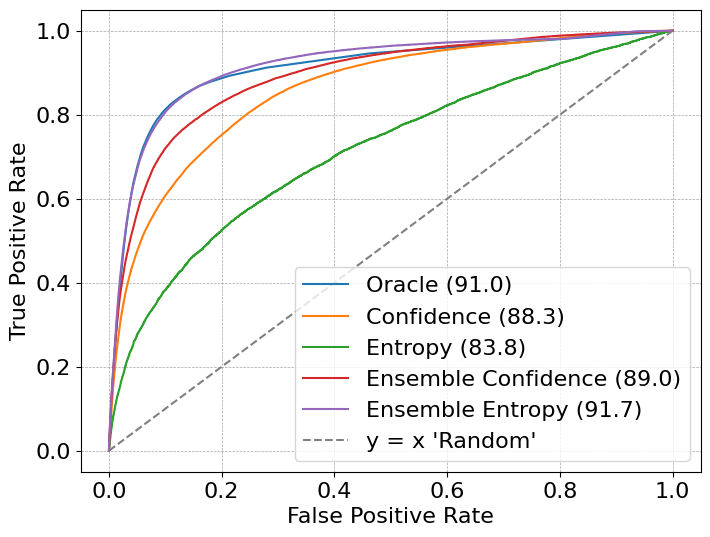

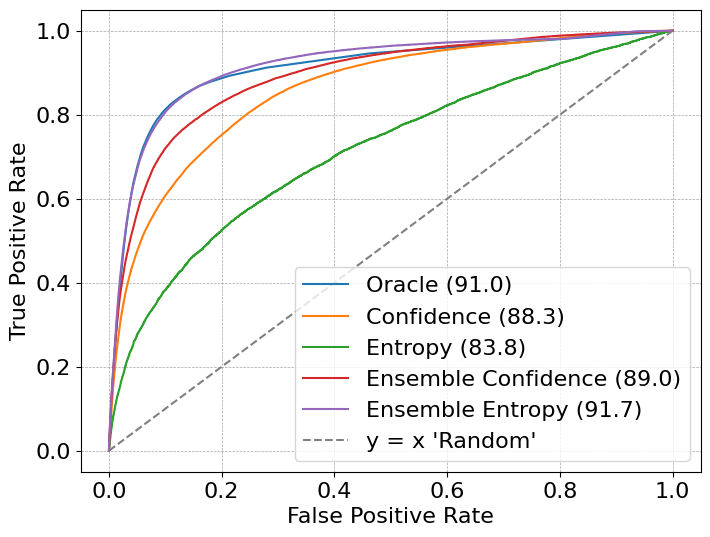

In [45]:
single_model_key = "clip_openclip_dfn2b_ViT-L-14-quickgelu" # maybe use openai pretrained?
main_object_values = unc_scores_clips["is_main_object"]
entropy_values = unc_scores_clips[single_model_key]["entropy"]
res_main_object, res_ent = clean_from_nan(main_object_values, entropy_values)

plot_multiple_pr_curves(
    [
        (
            iou_results,
            oracle_results,
            "Oracle (91.0)"
        ),
        (
            unc_scores_clips["is_main_object"],
            unc_scores_clips[single_model_key]["conf"],
            "Confidence (88.3)"
        ),
        (
            res_main_object,
            res_ent,
            "Entropy (83.8)",
        ),
        # (
        #     unc_scores_clips["is_main_object"],
        #     unc_scores_clips['ensemble']["energy"],
        #     "ens_energy"
        # ),
        (
            unc_scores_clips["is_main_object"],
            unc_scores_clips['ensemble']["ens_conf"],
            "Ensemble Confidence (89.0)"
        ),
        # (
        #     unc_scores_clips["is_main_object"],
        #     unc_scores_clips['ensemble']["PDS"],
        #     "PDS"
        # ),
        (
            unc_scores_clips["is_main_object"],
            unc_scores_clips['ensemble']["ens_ent"],
            "Ensemble Entropy (91.7)"
        ),

    ],
    # "ROC curves",
    pr=False,
    fontsize=16,
    title=None,
    save_path="/home/oh/arubinstein17/github/densification/tmp/ICCV2025-OCCAM/ICCV2025-Author-Kit-Feb/figures/roc.pdf"
)

## Reproduce old results

### Preparing models

In [2]:
# old resnet-vit models
res_path = "/home/oh/arubinstein17/github/densification/data/results/uncertainty_scores/5models_ensemble.pkl"

assert os.path.exists(res_path)

res = torch.load(res_path)
# 11m50s

In [ ]:
# merge res and oracle_results - plot curve for it + compute rocauc

In [ ]:
# # model
# assert dataloader is not None

# # eval

# model_list = make_models(
#     [
#         'resnet50.a1_in1k',
#         'resnet18.a1_in1k',
#         'vit_base_patch8_224.augreg2_in21k_ft_in1k',
#         'tf_efficientnet_b1.ns_jft_in1k',
#         'efficientnet_lite0.ra_in1k'
#     ]
# )
# res_path = os.path.join(get_project_root_path(), "data", "results", "uncertainty_scores", "5models_ensemble.pkl")
# if not os.path.exists(res_path):
#     res = eval_model_list_on_dataloader(
#         model_list,
#         dataloader,
#         device=torch.device("cuda:0"),
#         # max_samples=100
#     )
#     torch.save(res, res_path)
# else:
#     res = torch.load(res_path)

In [10]:
unc_scores = compute_unc(res, label_key="is_main_object")

100%|██████████| 605835/605835 [13:43<00:00, 735.41it/s]  


In [12]:
unc_scores_path = "/home/oh/arubinstein17/github/densification/data/results/uncertainty_scores/5models_ensemble_unc_scores.pkl"
optionally_make_dir(unc_scores_path)
torch.save(unc_scores, unc_scores_path)

In [13]:
# print(roc_auc_score("resnet18.a1_in1k conf:", unc_scores["is_main_object"], unc_scores['resnet18.a1_in1k']["conf"]))
# print(roc_auc_score("resnet50.a1_in1k conf:", unc_scores["is_main_object"], unc_scores['resnet50.a1_in1k']["conf"]))
# print(roc_auc_score("resnet50.a1_in1k conf:", unc_scores["is_main_object"], unc_scores['resnet50.a1_in1k']["conf"]))
# print(roc_auc_score("resnet50.a1_in1k conf:", unc_scores["is_main_object"], unc_scores['resnet50.a1_in1k']["conf"]))
# print(roc_auc_score("resnet50.a1_in1k conf:", unc_scores["is_main_object"], unc_scores['resnet50.a1_in1k']["conf"]))
# # print(roc_auc_score(unc_scores["is_main_object"], unc_scores['resnet50.a1_in1k']["entropy"]))

models = [
    'resnet50.a1_in1k',
    'resnet18.a1_in1k',
    'vit_base_patch8_224.augreg2_in21k_ft_in1k',
    'tf_efficientnet_b1.ns_jft_in1k',
    'efficientnet_lite0.ra_in1k'
]

?? use print_roc_auc_scores(model_names, unc_scores)

for model_id in models:
    print(f"{model_id} conf:", roc_auc_score(unc_scores["is_main_object"], unc_scores[model_id]["conf"]))

print("Energy:", roc_auc_score(unc_scores["is_main_object"], unc_scores['ensemble']["energy"]))
print("PDS:", roc_auc_score(unc_scores["is_main_object"], unc_scores['ensemble']["PDS"]))
print("ens_ent:", roc_auc_score(unc_scores["is_main_object"], unc_scores['ensemble']["ens_ent"]))
print("ens_conf:", roc_auc_score(unc_scores["is_main_object"], unc_scores['ensemble']["ens_conf"]))

resnet50.a1_in1k conf: 0.8855364217443009
resnet18.a1_in1k conf: 0.8761018794879284
vit_base_patch8_224.augreg2_in21k_ft_in1k conf: 0.867581340340267
tf_efficientnet_b1.ns_jft_in1k conf: 0.8605990810248737
efficientnet_lite0.ra_in1k conf: 0.8893524067641045
Energy: 0.8984064159688372
PDS: 0.6992523827015517
ens_ent: 0.9163355798810304
ens_conf: 0.9049494770794692


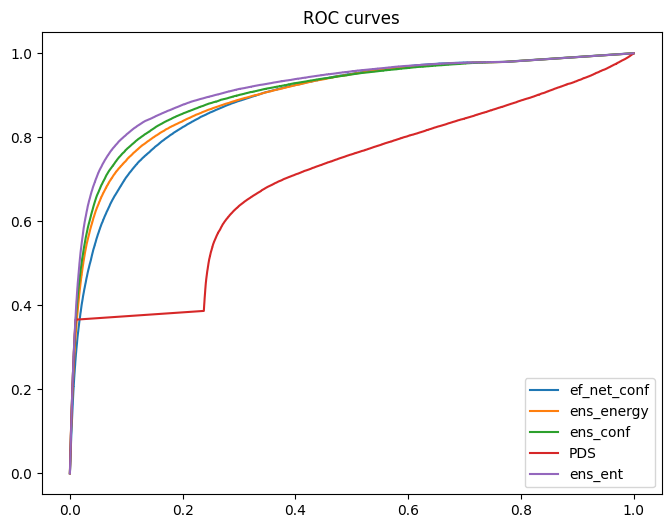

In [14]:
plot_multiple_pr_curves(
    [
        (
            unc_scores["is_main_object"],
            unc_scores['efficientnet_lite0.ra_in1k']["conf"],
            "ef_net_conf"
        ),
        (
            unc_scores["is_main_object"],
            unc_scores['ensemble']["energy"],
            "ens_energy"
        ),
        (
            unc_scores["is_main_object"],
            unc_scores['ensemble']["ens_conf"],
            "ens_conf"
        ),
        (
            unc_scores["is_main_object"],
            unc_scores['ensemble']["PDS"],
            "PDS"
        ),
        (
            unc_scores["is_main_object"],
            unc_scores['ensemble']["ens_ent"],
            "ens_ent"
        ),

    ],
    "ROC curves",
    pr=False
)